✓ 폰트 파일 발견: DIN_1451_LT_Pro_Engschrift.otf
✓ 폰트 파일 발견: DIN_2014_Bold_Italic.otf
✓ 폰트 파일 발견: DIN_2014_Demi.otf
✓ 폰트 파일 발견: DIN_2014_Extra_Bold_Italic.otf
✓ 폰트 파일 발견: DIN_2014_Extra_Light_Italic.otf
✓ 폰트 파일 발견: DIN_2014_Narrow_Demi.otf
✓ 폰트 파일 발견: DIN_2014_Narrow_Light.otf
✓ 폰트 파일 발견: DIN_2014.otf
✓ 폰트 파일 발견: DIN_Condensed_Light.otf
✓ 폰트 파일 발견: DIN_Condensed_VF.otf
✓ 폰트 파일 발견: DIN_Condensed.otf

총 11개의 DIN 폰트 파일을 찾았습니다.

✓ 등록 성공: DIN 1451 LT Pro Engschrift (DIN_1451_LT_Pro_Engschrift.otf)
✓ 등록 성공: DIN 2014 (DIN_2014_Bold_Italic.otf)
✓ 등록 성공: DIN 2014 (DIN_2014_Demi.otf)
✓ 등록 성공: DIN 2014 (DIN_2014_Extra_Bold_Italic.otf)
✓ 등록 성공: DIN 2014 (DIN_2014_Extra_Light_Italic.otf)
✓ 등록 성공: DIN 2014 Narrow (DIN_2014_Narrow_Demi.otf)
✓ 등록 성공: DIN 2014 Narrow (DIN_2014_Narrow_Light.otf)
✓ 등록 성공: DIN 2014 (DIN_2014.otf)
✓ 등록 성공: DIN Condensed (DIN_Condensed_Light.otf)
✓ 등록 성공: DIN Condensed VF (DIN_Condensed_VF.otf)
✓ 등록 성공: DIN Condensed (DIN_Condensed.otf)

총 11개의 폰트가 등록되었습니다.

matplotlib에서 인식된 DIN 

/tmp/ipykernel_1610287/379566279.py:173: UserWarning: Glyph 52629 (\N{HANGUL SYLLABLE CUG}) missing from font(s) DIN 2014.
  plt.tight_layout()
/root/miniforge3/envs/pyscf2/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 52629 (\N{HANGUL SYLLABLE CUG}) missing from font(s) DIN 2014.
  fig.canvas.print_figure(bytes_io, **kw)


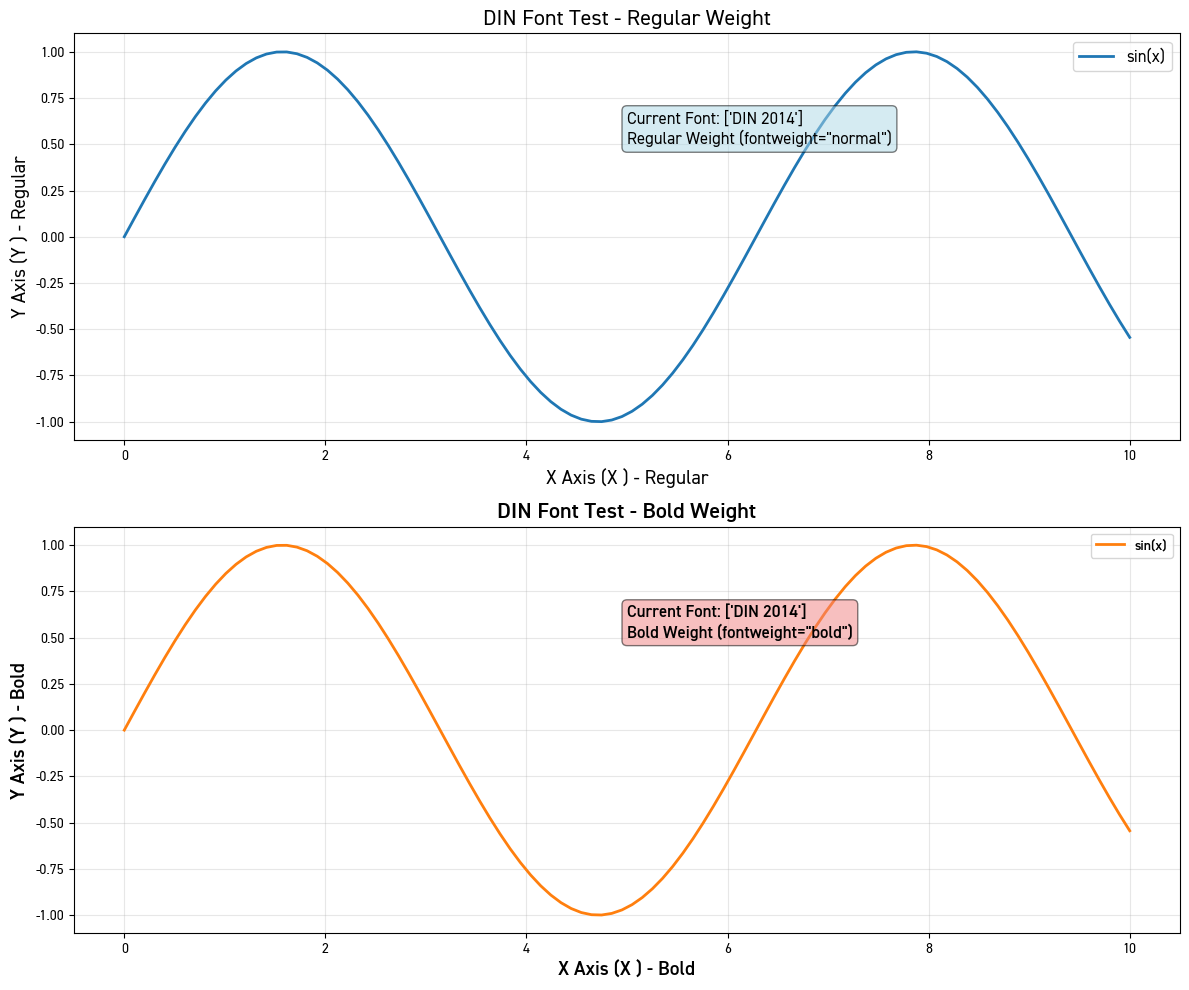


다양한 Font Weight 비교 테스트...
✓ Normal (normal): 테스트 완료
✓ Bold (bold): 테스트 완료
✓ Light (light): 테스트 완료
✓ Heavy (heavy): 테스트 완료
✓ Black (black): 테스트 완료


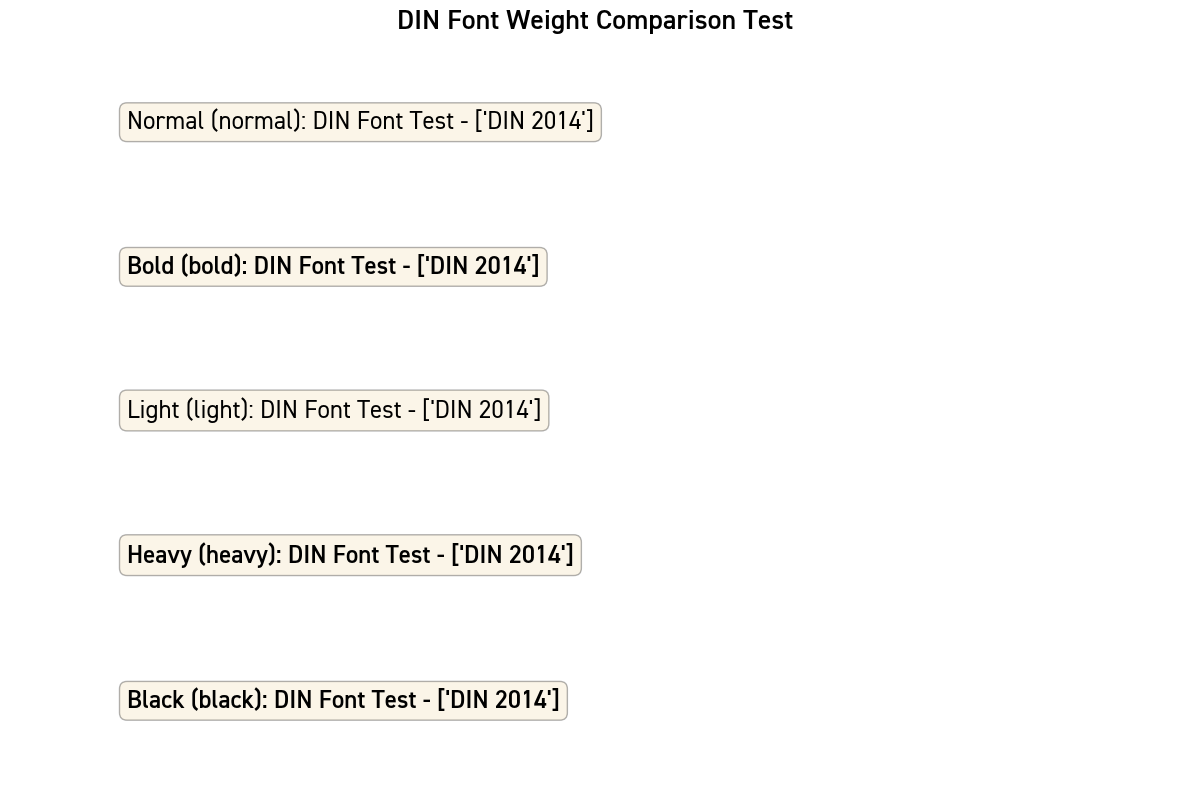


DIN 특정 Weight 직접 테스트...
✓ Condensed (DIN Condensed): 테스트 완료
✓ Regular (DIN 2014): 테스트 완료


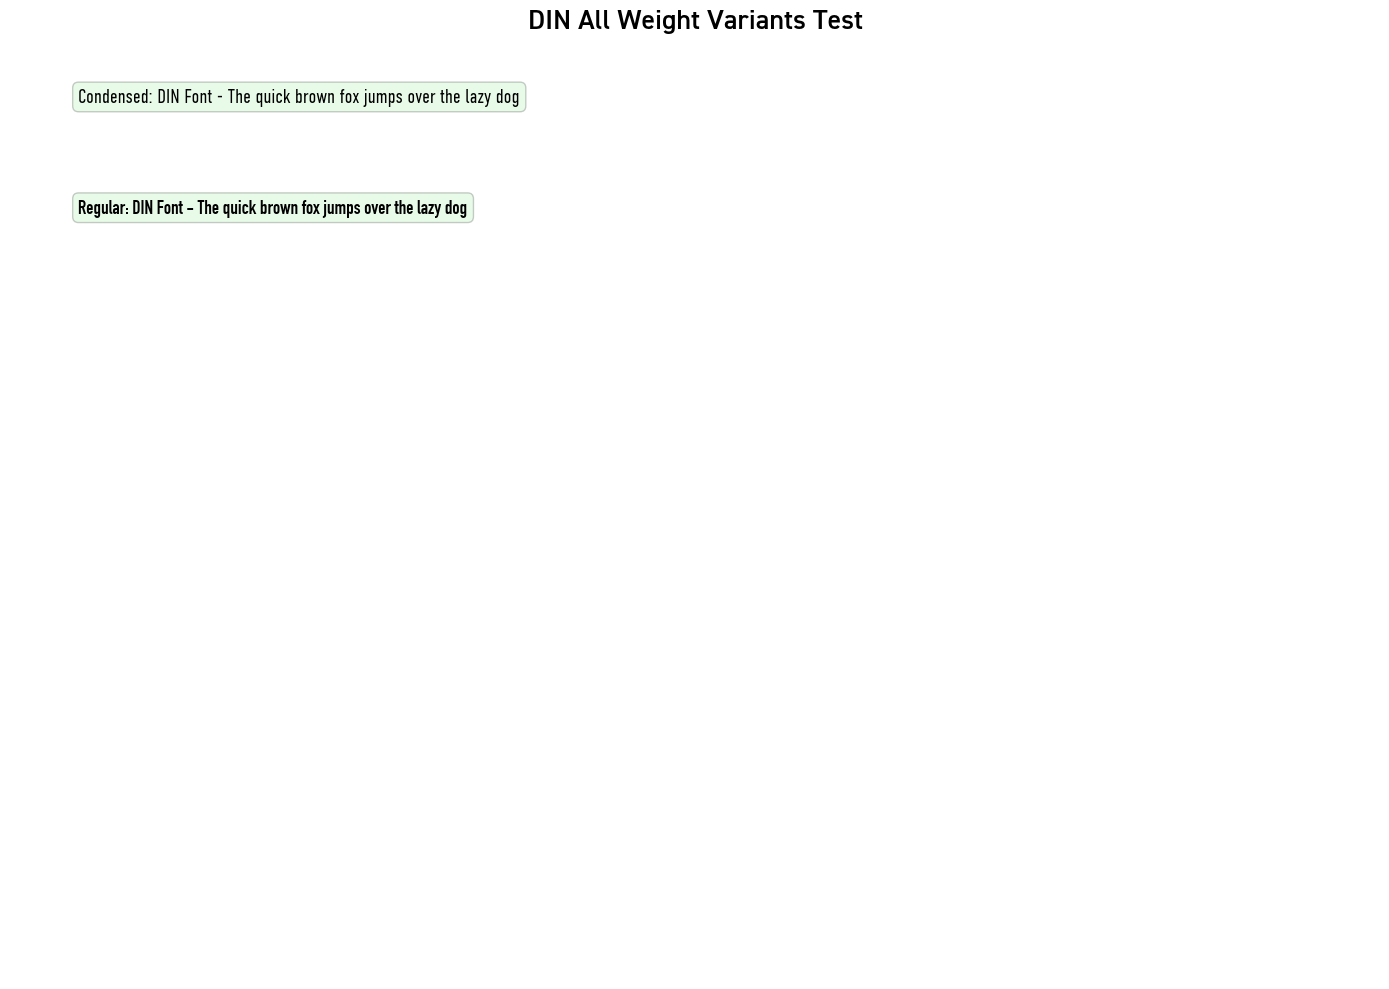


✓ 모든 테스트 플롯이 생성되었습니다.
  현재 사용 중인 폰트: ['DIN 2014']
  Bold 폰트 사용 가능: False


In [1]:
# DIN 폰트 설치 및 설정
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import os
import numpy as np

# DIN 폰트 파일 경로
font_dir = '/root/25DFT/font'

# 폰트 디렉토리에서 모든 DIN 폰트 파일 찾기
font_files = []
if os.path.exists(font_dir):
    for file in os.listdir(font_dir):
        if file.lower().endswith(('.otf', '.ttf', '.ttc')) and 'din' in file.lower():
            font_path = os.path.join(font_dir, file)
            font_files.append(font_path)
            print(f"✓ 폰트 파일 발견: {file}")

print(f"\n총 {len(font_files)}개의 DIN 폰트 파일을 찾았습니다.\n")

# matplotlib에 폰트 직접 등록
registered_fonts = []
for font_path in font_files:
    try:
        # 폰트를 matplotlib에 직접 추가
        fm.fontManager.addfont(font_path)
        # 폰트 정보 가져오기
        font_prop = fm.FontProperties(fname=font_path)
        font_name = font_prop.get_name()
        registered_fonts.append((font_name, font_path))
        print(f"✓ 등록 성공: {font_name} ({os.path.basename(font_path)})")
    except Exception as e:
        print(f"✗ 등록 실패: {os.path.basename(font_path)} - {str(e)}")

# 등록된 폰트 확인
if registered_fonts:
    print(f"\n총 {len(registered_fonts)}개의 폰트가 등록되었습니다.")
    
    # matplotlib에서 인식된 DIN 폰트 확인
    all_fonts = sorted(set([f.name for f in fm.fontManager.ttflist]))
    din_fonts = [f for f in all_fonts if 'din' in f.lower()]
    
    print(f"\nmatplotlib에서 인식된 DIN 폰트:")
    for font in din_fonts:
        print(f"  - {font}")
    
    # DIN_2014 우선 사용, 없으면 DIN-Regular 사용
    din_font_props = [f for f in fm.fontManager.ttflist if 'DIN' in f.name or 'din' in f.name.lower()]
    if din_font_props:
        # DIN_2014 폰트 우선 찾기
        din_2014 = [f for f in din_font_props if '2014' in f.name and 'Bold' not in f.name and 'Italic' not in f.name and 'Demi' not in f.name and 'Narrow' not in f.name and 'Extra' not in f.name]
        if din_2014:
            din_font_name = din_2014[0].name
        else:
            # DIN_2014가 없으면 일반 DIN-Regular 사용
            din_regular = [f for f in din_font_props if 'Bold' not in f.name and 'Italic' not in f.name and 'Condensed' not in f.name and 'Exp' not in f.name and '2014' not in f.name]
            if din_regular:
                din_font_name = din_regular[0].name
            else:
                # Regular가 없으면 첫 번째 DIN 폰트 사용
                din_font_name = din_font_props[0].name
        
        plt.rcParams['font.family'] = din_font_name
        plt.rcParams['font.sans-serif'] = [din_font_name] + plt.rcParams['font.sans-serif']
        print(f"\n✓ DIN 폰트를 기본 폰트로 설정했습니다: {din_font_name}")
    else:
        # 등록은 되었지만 이름이 다른 경우
        din_font_name = registered_fonts[0][0]
        plt.rcParams['font.family'] = din_font_name
        plt.rcParams['font.sans-serif'] = [din_font_name] + plt.rcParams['font.sans-serif']
        print(f"\n✓ DIN 폰트를 기본 폰트로 설정했습니다: {din_font_name}")
else:
    # DIN이 없으면 대체 폰트 사용
    available_fonts = [f.name for f in fm.fontManager.ttflist]
    if 'Arial' in available_fonts:
        plt.rcParams['font.family'] = 'Arial'
        print("\n⚠ DIN 폰트를 찾을 수 없습니다. Arial 폰트를 사용합니다.")
    elif 'Helvetica' in available_fonts:
        plt.rcParams['font.family'] = 'Helvetica'
        print("\n⚠ DIN 폰트를 찾을 수 없습니다. Helvetica 폰트를 사용합니다.")
    else:
        plt.rcParams['font.family'] = 'DejaVu Sans'
        print("\n⚠ DIN 폰트를 찾을 수 없습니다. DejaVu Sans 폰트를 사용합니다.")

plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호는 유지

# Bold 폰트 확인
print("\n" + "="*50)
print("DIN Bold 폰트 확인 중...")
print("="*50)

# Bold 폰트 파일이 있는지 확인
bold_font_files = [f for f in font_files if 'bold' in os.path.basename(f).lower() and 'italic' not in os.path.basename(f).lower()]
if bold_font_files:
    print(f"✓ Bold 폰트 파일 발견: {[os.path.basename(f) for f in bold_font_files]}")
    bold_available = True
else:
    print("⚠ 별도의 Bold 폰트 파일이 없습니다. (synthetic bold 사용 가능)")
    bold_available = False

# Bold 폰트 이름 확인 (DIN_2014 Bold 우선)
din_font_props = [f for f in fm.fontManager.ttflist if 'DIN' in f.name or 'din' in f.name.lower()]
# DIN_2014 Bold 우선 찾기
din_2014_bold = [f for f in din_font_props if '2014' in f.name and 'Bold' in f.name and 'Italic' not in f.name]
bold_font_names = [f.name for f in din_2014_bold] if din_2014_bold else [f.name for f in din_font_props if 'Bold' in f.name and 'Italic' not in f.name]
if bold_font_names:
    print(f"✓ Bold 폰트 이름: {bold_font_names}")
else:
    print("⚠ Bold 폰트 이름이 인식되지 않았습니다. (fontweight='bold'로 synthetic bold 시도)")
    
# 사용 가능한 모든 DIN weight 확인
print(f"\n사용 가능한 DIN 폰트 weight:")
weight_variants = {}
for font_prop in din_font_props:
    name = font_prop.name
    if 'Italic' not in name:
        if 'Bold' in name:
            weight_variants['Bold'] = name
        elif 'Condensed' in name:
            if 'Bold' in name:
                weight_variants['Condensed Bold'] = name
            else:
                weight_variants['Condensed'] = name
        elif 'Exp' in name:
            if 'Bold' in name:
                weight_variants['Exp Bold'] = name
            else:
                weight_variants['Exp'] = name
        else:
            weight_variants['Regular'] = name
            
for weight, name in sorted(weight_variants.items()):
    print(f"  - {weight}: {name}")

# 테스트 플롯 생성 - Regular vs Bold 비교
print("\n" + "="*50)
print("DIN 폰트 테스트 플롯 생성 중 (Regular & Bold 비교)...")
print("="*50)

fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# 첫 번째 플롯: 기본 테스트
ax1 = axes[0]
x = np.linspace(0, 10, 100)
y = np.sin(x)

ax1.plot(x, y, linewidth=2, label='sin(x)')
ax1.set_xlabel('X Axis (X축) - Regular', fontsize=14)
ax1.set_ylabel('Y Axis (Y축) - Regular', fontsize=14)
ax1.set_title('DIN Font Test - Regular Weight', fontsize=16, fontweight='normal')
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=12)

current_font = plt.rcParams['font.family']
ax1.text(5, 0.5, f'Current Font: {current_font}\nRegular Weight (fontweight="normal")', 
        fontsize=12, bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

# 두 번째 플롯: Bold 테스트
ax2 = axes[1]
ax2.plot(x, y, linewidth=2, label='sin(x)', color='C1')
ax2.set_xlabel('X Axis (X축) - Bold', fontsize=14, fontweight='bold')
ax2.set_ylabel('Y Axis (Y축) - Bold', fontsize=14, fontweight='bold')
ax2.set_title('DIN Font Test - Bold Weight', fontsize=16, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=12, prop={'weight': 'bold'})

# Bold 텍스트 추가
bold_text = f'Current Font: {current_font}\nBold Weight (fontweight="bold")'
ax2.text(5, 0.5, bold_text, 
        fontsize=12, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.5))

plt.tight_layout()
plt.show()

# 추가 테스트: 다양한 fontweight 비교
print("\n" + "="*50)
print("다양한 Font Weight 비교 테스트...")
print("="*50)

fig, ax = plt.subplots(figsize=(12, 8))
ax.axis('off')

# 다양한 fontweight 테스트
weights = ['normal', 'bold', 'light', 'heavy', 'black']
weight_names = ['Normal', 'Bold', 'Light', 'Heavy', 'Black']
y_positions = np.linspace(0.9, 0.1, len(weights))

test_text = f"DIN Font Test - {current_font}"

for i, (weight, name) in enumerate(zip(weights, weight_names)):
    try:
        ax.text(0.1, y_positions[i], f'{name} ({weight}): {test_text}', 
               fontsize=18, fontweight=weight, 
               transform=ax.transAxes,
               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
        print(f"✓ {name} ({weight}): 테스트 완료")
    except Exception as e:
        ax.text(0.1, y_positions[i], f'{name} ({weight}): [ERROR - {str(e)}]', 
               fontsize=18, transform=ax.transAxes,
               bbox=dict(boxstyle='round', facecolor='red', alpha=0.3))
        print(f"✗ {name} ({weight}): 오류 - {str(e)}")

ax.set_title('DIN Font Weight Comparison Test', fontsize=20, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# DIN 특정 weight 직접 테스트
if 'weight_variants' in locals() and weight_variants:
    print("\n" + "="*50)
    print("DIN 특정 Weight 직접 테스트...")
    print("="*50)
    
    # weight 이름과 파일 경로 매핑 생성
    weight_to_file = {}
    for f_path in font_files:
        fname = os.path.basename(f_path).lower()
        if 'italic' not in fname:
            if 'bold' in fname:
                if 'condensed' in fname and 'Condensed Bold' not in weight_to_file:
                    weight_to_file['Condensed Bold'] = f_path
                elif 'exp' in fname and 'Exp Bold' not in weight_to_file:
                    weight_to_file['Exp Bold'] = f_path
                elif 'Bold' not in weight_to_file:
                    weight_to_file['Bold'] = f_path
            elif 'condensed' in fname and 'Condensed' not in weight_to_file:
                weight_to_file['Condensed'] = f_path
            elif 'exp' in fname and 'Exp' not in weight_to_file:
                weight_to_file['Exp'] = f_path
            elif 'Regular' not in weight_to_file:
                weight_to_file['Regular'] = f_path
    
    fig, ax = plt.subplots(figsize=(14, 10))
    ax.axis('off')
    
    y_pos = 0.95
    test_text_base = "DIN Font - The quick brown fox jumps over the lazy dog"
    
    for weight_name, font_name in sorted(weight_variants.items()):
        try:
            # 파일 경로 찾기
            font_path = None
            if weight_name in weight_to_file:
                font_path = weight_to_file[weight_name]
            else:
                # registered_fonts에서 찾기
                for reg_name, reg_path in registered_fonts:
                    if font_name in reg_name:
                        font_path = reg_path
                        break
            
            if font_path and os.path.exists(font_path):
                font_prop = fm.FontProperties(fname=font_path)
                ax.text(0.05, y_pos, f'{weight_name}: {test_text_base}', 
                       fontsize=14, fontproperties=font_prop,
                       transform=ax.transAxes,
                       bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.2))
                print(f"✓ {weight_name} ({font_name}): 테스트 완료")
            else:
                # 폰트 이름으로 직접 사용
                font_prop = fm.FontProperties(family=font_name)
                ax.text(0.05, y_pos, f'{weight_name}: {test_text_base}', 
                       fontsize=14, fontproperties=font_prop,
                       transform=ax.transAxes,
                       bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.2))
                print(f"✓ {weight_name} ({font_name}): 테스트 완료 (이름으로)")
            y_pos -= 0.12
        except Exception as e:
            ax.text(0.05, y_pos, f'{weight_name}: [ERROR - {str(e)}]', 
                   fontsize=14, transform=ax.transAxes,
                   bbox=dict(boxstyle='round', facecolor='red', alpha=0.3))
            print(f"✗ {weight_name}: 오류 - {str(e)}")
            y_pos -= 0.12
    
    ax.set_title('DIN All Weight Variants Test', fontsize=20, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()

print(f"\n✓ 모든 테스트 플롯이 생성되었습니다.")
print(f"  현재 사용 중인 폰트: {plt.rcParams['font.family']}")
if 'bold_available' in locals():
    print(f"  Bold 폰트 사용 가능: {bold_available}")

result_malon_dft rOH range: [0.900000, 1.700000]
result_malon_qhflow rOH range: [0.900000, 1.700000]
results_malon_qhflow_single_point rOH range: [0.899982, 1.694930]
result_malon_nequip_single_point rOH range: [0.899982, 1.694930]
Overall rOH range: [0.899982, 1.700000]
saved: /root/25DFT/QHFlow/_asset/malon_draw/data/plot/malon_all_lines_vs_rOH_20260115_214809.png


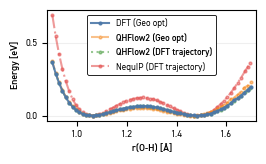

In [18]:
# malon_draw/data 폴더 안의 지정된 결과만 플롯
from pathlib import Path
from datetime import datetime
import matplotlib.pyplot as plt
import numpy as np

data_dir = Path("/root/25DFT/QHFlow/_asset/malon_draw/data")

# 이 리스트에 폴더명을 추가하면 자동으로 포함됩니다.
TARGET_DIRS = [
    "result_malon_dft",
    "result_malon_qhflow",
    "results_malon_qhflow_single_point",
    "result_malon_nequip_single_point",
]

# 각 데이터셋의 입력 에너지 단위를 적어주세요. ("eV" 또는 "Ha")
INPUT_ENERGY_LABELS = {
    "result_malon_nequip_single_point": "eV",
    "result_malon_dft": "eV",
    "result_malon_qhflow": "eV",
    "results_malon_qhflow_single_point": "eV",
}

# 에너지 단위 옵션: 기본 eV, Ha(하트리)를 eV로 변환 가능
DEFAULT_INPUT_ENERGY = "eV"  # "eV" or "Ha"

# 플롯 스타일 옵션
DEFAULT_LINE_ALPHA = 0.6
MARKER_SIZE = 2
LINE_WIDTH = 1.5

LABEL_FS = 7
ANNOT_FS = 6.5
TICK_FS = 7

LINE_STYLES = {
    "result_malon_dft": "-",
    "result_malon_qhflow": "--",
    "results_malon_qhflow_single_point": ":",
    "result_malon_nequip_single_point": "-.",
}

LINE_ALPHAS = {
    "result_malon_dft": 0.9,
    "result_malon_qhflow": 0.5,
    "results_malon_qhflow_single_point": 0.6,
    "result_malon_nequip_single_point": 0.6,
}

# 겹치는 곡선을 보기 위한 시각적 오프셋 (단위: eV)
VISUAL_OFFSETS = {
    "result_malon_dft": 0.02,
}

# 그리기 순서 (값이 클수록 위에 표시)
ZORDERS = {
    "result_malon_dft": 5,
    "result_malon_qhflow": 4,
    "results_malon_qhflow_single_point": 3,
    "result_malon_nequip_single_point": 2,
}

# 축 범위 옵션 (None이면 자동)
XLIM = (0.88,1.72)  # 예: (0.9, 1.6)
YLIM = None  # 예: (0.0, 2.5)

# DFT 기준 데이터셋 이름
DFT_KEY = "result_malon_dft"

HA_TO_EV = 27.211386245988

myblue = "#4C78A8"
myorange = "#F58518"
mygreen = "#54A24B"
myred = "#E45756"

COLOR_MAP = {
    "result_malon_dft": myblue,
    "result_malon_qhflow": myorange,
    "results_malon_qhflow_single_point": mygreen,
    "result_malon_nequip_single_point": myred,
}

# 저장용 타임스탬프 및 경로
timestamp_label = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
timestamp_file = datetime.now().strftime("%Y%m%d_%H%M%S")
plot_dir = data_dir / "plot"
plot_dir.mkdir(parents=True, exist_ok=True)


def pretty_label(name: str) -> str:
    base = name.replace("results_", "").replace("result_", "")
    base = base.replace("malon_", "")
    base = base.replace("single_point", "")
    base = base.replace("_", " ")
    base = (
        base.replace("qhflow", "QHFlow2")
        .replace("nequip", "NequIP")
        .replace("dft", "DFT")
    )
    base = " ".join([w.capitalize() if w.islower() else w for w in base.split()])
    suffix = "(DFT trajectory)" if "single_point" in name else "(Geo opt)"
    return f"{base} {suffix}"

subdirs = [data_dir / name for name in TARGET_DIRS]

# 에너지-결합거리(rOH) 곡선 플롯 (지정된 폴더만)
ratio = 1.2
plt.figure(figsize=(2.3*ratio, 1.45*ratio))
plotted = False

data_by_name = {}

x_min_all = None
x_max_all = None
for subdir in subdirs:
    if not subdir.exists():
        print(f"skip {subdir.name}: 폴더가 없습니다.")
        continue

    r_files = sorted(subdir.glob("*rOH*.npy"))
    e_files = sorted(subdir.glob("*energies*.npy"))
    if not r_files or not e_files:
        print(f"skip {subdir.name}: rOH/energies npy 파일 없음")
        continue

    r = np.load(r_files[0]).reshape(-1)
    r_min = float(np.min(r))
    r_max = float(np.max(r))
    print(f"{subdir.name} rOH range: [{r_min:.6f}, {r_max:.6f}]")

    if x_min_all is None:
        x_min_all = r_min
        x_max_all = r_max
    else:
        x_min_all = min(x_min_all, r_min)
        x_max_all = max(x_max_all, r_max)

    input_unit = INPUT_ENERGY_LABELS.get(subdir.name, DEFAULT_INPUT_ENERGY)
    if input_unit == "Ha":
        energy_scale = HA_TO_EV
    else:
        energy_scale = 1.0

    e = np.load(e_files[0]).reshape(-1) * energy_scale
    if r.shape[0] != e.shape[0]:
        print(f"skip {subdir.name}: rOH({r.shape}) vs energies({e.shape}) 길이 불일치")
        continue

    # 원본 에너지 보관 (reference value 빼기 전)
    e_raw = e.copy()

    # 최소값 기준 상대 에너지로 변환
    e = e - np.min(e)

    # 원본/상대 에너지 모두 저장
    data_by_name[subdir.name] = {"r": r, "e": e, "e_raw": e_raw}

    # 겹침 방지를 위한 시각적 오프셋 (표시용)
    # offset = VISUAL_OFFSETS.get(subdir.name, 0.0)
    # e = e + offset

    plotted = True

if plotted:
    if x_min_all is not None:
        print(f"Overall rOH range: [{x_min_all:.6f}, {x_max_all:.6f}]")

    # 각 데이터셋 에너지/거리 값을 변수로 저장
    # energies_by_name: reference value 빼기 전 원본 에너지
    energies_by_name = {name: data["e_raw"] for name, data in data_by_name.items()}
    energies_rel_by_name = {name: data["e"] for name, data in data_by_name.items()}
    r_by_name = {name: data["r"] for name, data in data_by_name.items()}

    if DFT_KEY not in data_by_name:
        print("DFT 데이터가 없어 그래프를 생성하지 못했습니다.")
    else:
        # 각 데이터셋을 개별 곡선으로 플롯
        for name in TARGET_DIRS:
            if name not in data_by_name:
                continue
            r_vals = data_by_name[name]["r"]
            e_vals = data_by_name[name]["e"]

            label = pretty_label(name)
            linestyle = LINE_STYLES.get(name, "-")
            alpha = LINE_ALPHAS.get(name, DEFAULT_LINE_ALPHA)
            color = COLOR_MAP.get(name, "#333333")
            zorder = ZORDERS.get(name, 1)

            plt.plot(
                r_vals,
                e_vals,
                marker="o",
                markersize=MARKER_SIZE,
                linewidth=LINE_WIDTH,
                alpha=alpha,
                linestyle=linestyle,
                color=color,
                zorder=zorder,
                label=label,
            )

        plt.xlabel("r(O-H) [Å]", fontsize=LABEL_FS, fontweight="bold")
        plt.ylabel("Energy [eV]", fontsize=LABEL_FS, fontweight="bold")
        plt.xticks(fontsize=TICK_FS)
        plt.yticks(fontsize=TICK_FS)
        if XLIM is not None:
            plt.xlim(XLIM)
        if YLIM is not None:
            plt.ylim(YLIM)
        plt.grid(True, axis="y", alpha=0.2)
        legend = plt.legend(framealpha=1, frameon=True, edgecolor="black", prop={"size": ANNOT_FS})
        legend.get_frame().set_linewidth(0.6)
        for text in legend.get_texts():
            if "QHFlow2" in text.get_text():
                text.set_fontweight("bold")
        plt.tight_layout()

        plot_path = plot_dir / f"malon_all_lines_vs_rOH_{timestamp_file}.png"
        plt.savefig(plot_path, dpi=300, bbox_inches="tight")
        print(f"saved: {plot_path}")

        plt.show()
else:
    print("플롯할 rOH/energies 데이터가 없습니다.")

# # 폴더 내 PNG 이미지 표시 (지정된 폴더만)
# png_files = []
# for subdir in subdirs:
#     if subdir.exists():
#         png_files.extend(sorted(subdir.glob("*.png")))

# if png_files:
#     cols = 2
#     rows = int(np.ceil(len(png_files) / cols))
#     fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 4 * rows))
#     axes = np.atleast_1d(axes).ravel()

#     for ax, png_path in zip(axes, png_files):
#         img = plt.imread(png_path)
#         ax.imshow(img)
#         ax.set_title(f"{png_path.parent.name}: {png_path.name}")
#         ax.axis("off")

#     for ax in axes[len(png_files):]:
#         ax.axis("off")

#     plt.tight_layout()
#     plt.show()
# else:
#     print("표시할 PNG 이미지가 없습니다.")


In [19]:
energies_by_name["result_malon_qhflow"]

array([3.70827126e-01, 2.93814583e-01, 2.28612812e-01, 1.74227653e-01,
       1.29163781e-01, 9.30375098e-02, 6.41030691e-02, 4.17515247e-02,
       2.50458654e-02, 1.32024065e-02, 5.49238677e-03, 1.53243803e-03,
       9.98360647e-05, 9.88885710e-04, 3.67357357e-03, 7.69330358e-03,
       1.26526023e-02, 1.81823518e-02, 2.39567604e-02, 2.97000159e-02,
       3.51540756e-02, 4.01303933e-02, 4.44497660e-02, 4.79824112e-02,
       5.06178135e-02, 5.22885260e-02, 5.29463623e-02, 5.26013193e-02,
       5.12695452e-02, 4.87317674e-02, 4.56041134e-02, 4.17547722e-02,
       3.75136822e-02, 3.25665665e-02, 2.73327063e-02, 2.20027131e-02,
       1.67877562e-02, 1.19132152e-02, 7.60531388e-03, 4.09343173e-03,
       1.33232345e-03, 0.00000000e+00, 6.66919841e-05, 1.66283170e-03,
       4.68119965e-03, 9.60995919e-03, 1.62021231e-02, 2.67246518e-02,
       3.40409810e-02, 4.55942375e-02, 5.87594721e-02, 7.29036903e-02,
       8.86840521e-02, 1.14522781e-01, 1.23776011e-01, 1.42849661e-01,
      

In [20]:
energies_by_name["result_malon_nequip_single_point"]

array([-7256.05419922, -7256.19970703, -7256.32128906, -7256.42431641,
       -7256.5078125 , -7256.57617188, -7256.62939453, -7256.67089844,
       -7256.70117188, -7256.72167969, -7256.73486328, -7256.7421875 ,
       -7256.74316406, -7256.74023438, -7256.73388672, -7256.72363281,
       -7256.71289062, -7256.70068359, -7256.68847656, -7256.67480469,
       -7256.6640625 , -7256.65234375, -7256.64257812, -7256.63476562,
       -7256.62841797, -7256.62451172, -7256.62109375, -7256.61865234,
       -7256.62353516, -7256.62695312, -7256.63037109, -7256.63964844,
       -7256.64892578, -7256.65722656, -7256.66943359, -7256.68066406,
       -7256.69335938, -7256.70361328, -7256.71435547, -7256.72509766,
       -7256.73242188, -7256.73828125, -7256.74316406, -7256.74316406,
       -7256.74121094, -7256.73779297, -7256.72900391, -7256.71777344,
       -7256.703125  , -7256.68457031, -7256.6640625 , -7256.64013672,
       -7256.61474609, -7256.5859375 , -7256.55419922, -7256.52050781,
      

result_malon_dft rOH range: [0.900000, 1.700000]
results_malon_qhflow_single_point rOH range: [0.899982, 1.694930]
result_malon_nequip_single_point rOH range: [0.899982, 1.694930]
Overall rOH range: [0.899982, 1.700000]
saved: /root/25DFT/QHFlow/_asset/malon_draw/data/plot/malon_energy_vs_rOH_20260115_213558.png


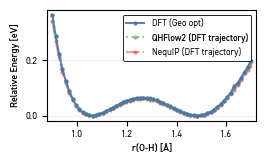

saved: /root/25DFT/QHFlow/_asset/malon_draw/data/plot/malon_energy_diff_vs_dft_20260115_213558.png


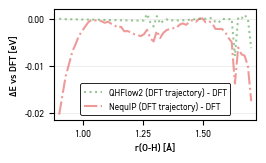

In [3]:
# malon_draw/data 폴더 안의 지정된 결과만 플롯
from pathlib import Path
from datetime import datetime
import matplotlib.pyplot as plt
import numpy as np

data_dir = Path("/root/25DFT/QHFlow/_asset/malon_draw/data")

# 이 리스트에 폴더명을 추가하면 자동으로 포함됩니다.
TARGET_DIRS = [
    "result_malon_dft",
    # "result_malon_qhflow",
    "results_malon_qhflow_single_point",
    "result_malon_nequip_single_point",
]

# 각 데이터셋의 입력 에너지 단위를 적어주세요. ("eV" 또는 "Ha")
INPUT_ENERGY_LABELS = {
    "result_malon_nequip_single_point": "eV",
    "result_malon_dft": "eV",
    "result_malon_qhflow": "eV",
    "results_malon_qhflow_single_point": "eV",
}

# 에너지 단위 옵션: 기본 eV, Ha(하트리)를 eV로 변환 가능
DEFAULT_INPUT_ENERGY = "eV"  # "eV" or "Ha"

# 플롯 스타일 옵션
DEFAULT_LINE_ALPHA = 0.6
MARKER_SIZE = 2
LINE_WIDTH = 1.5

LABEL_FS = 7
ANNOT_FS = 6.5
TICK_FS = 7

LINE_STYLES = {
    "result_malon_dft": "-",
    "result_malon_qhflow": "--",
    "results_malon_qhflow_single_point": ":",
    "result_malon_nequip_single_point": "-.",
}

LINE_ALPHAS = {
    "result_malon_dft": 0.9,
    "result_malon_qhflow": 0.5,
    "results_malon_qhflow_single_point": 0.6,
    "result_malon_nequip_single_point": 0.6,
}

# 겹치는 곡선을 보기 위한 시각적 오프셋 (단위: eV)
VISUAL_OFFSETS = {
    "result_malon_dft": 0.02,
}

# 그리기 순서 (값이 클수록 위에 표시)
ZORDERS = {
    "result_malon_dft": 5,
    "result_malon_qhflow": 4,
    "results_malon_qhflow_single_point": 3,
    "result_malon_nequip_single_point": 2,
}

# 축 범위 옵션 (None이면 자동)
XLIM = (0.88,1.72)  # 예: (0.9, 1.6)
YLIM = None  # 예: (0.0, 2.5)

# DFT 기준 데이터셋 이름
DFT_KEY = "result_malon_dft"

HA_TO_EV = 27.211386245988

myblue = "#4C78A8"
myorange = "#F58518"
mygreen = "#54A24B"
myred = "#E45756"

COLOR_MAP = {
    "result_malon_dft": myblue,
    "result_malon_qhflow": myorange,
    "results_malon_qhflow_single_point": mygreen,
    "result_malon_nequip_single_point": myred,
}

# 저장용 타임스탬프 및 경로
timestamp_label = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
timestamp_file = datetime.now().strftime("%Y%m%d_%H%M%S")
plot_dir = data_dir / "plot"
plot_dir.mkdir(parents=True, exist_ok=True)


def pretty_label(name: str) -> str:
    base = name.replace("results_", "").replace("result_", "")
    base = base.replace("malon_", "")
    base = base.replace("single_point", "")
    base = base.replace("_", " ")
    base = (
        base.replace("qhflow", "QHFlow2")
        .replace("nequip", "NequIP")
        .replace("dft", "DFT")
    )
    base = " ".join([w.capitalize() if w.islower() else w for w in base.split()])
    suffix = "(DFT trajectory)" if "single_point" in name else "(Geo opt)"
    return f"{base} {suffix}"

subdirs = [data_dir / name for name in TARGET_DIRS]

# 에너지-결합거리(rOH) 곡선 플롯 (지정된 폴더만)
ratio = 1.2
plt.figure(figsize=(2.3*ratio, 1.45*ratio))
plotted = False

data_by_name = {}

x_min_all = None
x_max_all = None
for subdir in subdirs:
    if not subdir.exists():
        print(f"skip {subdir.name}: 폴더가 없습니다.")
        continue

    r_files = sorted(subdir.glob("*rOH*.npy"))
    e_files = sorted(subdir.glob("*energies*.npy"))
    if not r_files or not e_files:
        print(f"skip {subdir.name}: rOH/energies npy 파일 없음")
        continue

    r = np.load(r_files[0]).reshape(-1)
    r_min = float(np.min(r))
    r_max = float(np.max(r))
    print(f"{subdir.name} rOH range: [{r_min:.6f}, {r_max:.6f}]")

    if x_min_all is None:
        x_min_all = r_min
        x_max_all = r_max
    else:
        x_min_all = min(x_min_all, r_min)
        x_max_all = max(x_max_all, r_max)

    input_unit = INPUT_ENERGY_LABELS.get(subdir.name, DEFAULT_INPUT_ENERGY)
    if input_unit == "Ha":
        energy_scale = HA_TO_EV
    else:
        energy_scale = 1.0

    e = np.load(e_files[0]).reshape(-1) * energy_scale
    if subdir.name == "result_malon_nequip_single_point":
        e = e * 0.5
    if r.shape[0] != e.shape[0]:
        print(f"skip {subdir.name}: rOH({r.shape}) vs energies({e.shape}) 길이 불일치")
        continue

    # 최소값 기준 상대 에너지로 변환
    e = e - np.min(e)

    # diff 계산을 위해 원본 상대 에너지 저장
    data_by_name[subdir.name] = {"r": r, "e": e}

    # 겹침 방지를 위한 시각적 오프셋 (표시용)
    # offset = VISUAL_OFFSETS.get(subdir.name, 0.0)
    # e = e + offset

    label = pretty_label(subdir.name)
    linestyle = LINE_STYLES.get(subdir.name, "-")
    alpha = LINE_ALPHAS.get(subdir.name, DEFAULT_LINE_ALPHA)
    color = COLOR_MAP.get(subdir.name, "#333333")
    zorder = ZORDERS.get(subdir.name, 1)
    plt.plot(
        r,
        e,
        marker="o",
        markersize=MARKER_SIZE,
        linewidth=LINE_WIDTH,
        alpha=alpha,
        linestyle=linestyle,
        color=color,
        zorder=zorder,
        label=label,
    )
    plotted = True

if plotted:
    if x_min_all is not None:
        print(f"Overall rOH range: [{x_min_all:.6f}, {x_max_all:.6f}]")
    plt.xlabel("r(O-H) [Å]", fontsize=LABEL_FS, fontweight="bold")
    plt.ylabel("Relative Energy [eV]", fontsize=LABEL_FS, fontweight="bold")
    plt.xticks(fontsize=TICK_FS)
    plt.yticks(fontsize=TICK_FS)
    if XLIM is not None:
        plt.xlim(XLIM)
    if YLIM is not None:
        plt.ylim(YLIM)
    plt.grid(True, axis="y", alpha=0.2)
    legend = plt.legend(framealpha=1, frameon=True, edgecolor="black", prop={"size": ANNOT_FS})
    legend.get_frame().set_linewidth(0.6)
    for text in legend.get_texts():
        if "QHFlow2" in text.get_text():
            text.set_fontweight("bold")
    plt.tight_layout()

    plot_path = plot_dir / f"malon_energy_vs_rOH_{timestamp_file}.png"
    plt.savefig(plot_path, dpi=300, bbox_inches="tight")
    print(f"saved: {plot_path}")

    plt.show()

    # DFT 기준 diff 플롯 (모든 데이터셋을 한 그래프에)
    if DFT_KEY in data_by_name:
        r_ref = data_by_name[DFT_KEY]["r"]
        e_ref = data_by_name[DFT_KEY]["e"]

        plt.figure(figsize=(2.3*ratio, 1.45*ratio))
        for name, data in data_by_name.items():
            if name == DFT_KEY:
                continue
            r_other = data["r"]
            e_other = data["e"]

            if r_other.shape == r_ref.shape and np.allclose(r_other, r_ref):
                e_interp = e_other
            else:
                order = np.argsort(r_other)
                e_interp = np.interp(r_ref, r_other[order], e_other[order])

            diff = e_interp - e_ref

            label = f"{pretty_label(name)} - DFT"
            linestyle = LINE_STYLES.get(name, "-")
            alpha = LINE_ALPHAS.get(name, DEFAULT_LINE_ALPHA)
            color = COLOR_MAP.get(name, "#333333")
            zorder = ZORDERS.get(name, 1)

            plt.plot(
                r_ref,
                diff,
                linewidth=LINE_WIDTH,
                alpha=alpha,
                linestyle=linestyle,
                color=color,
                zorder=zorder,
                label=label,
            )

        plt.xlabel("r(O-H) [Å]", fontsize=LABEL_FS, fontweight="bold")
        plt.ylabel("ΔE vs DFT [eV]", fontsize=LABEL_FS, fontweight="bold")
        plt.xticks(fontsize=TICK_FS)
        plt.yticks(fontsize=TICK_FS)
        if XLIM is not None:
            plt.xlim(XLIM)
        plt.grid(True, axis="y", alpha=0.2)
        legend = plt.legend(framealpha=1, frameon=True, edgecolor="black", prop={"size": ANNOT_FS})
        legend.get_frame().set_linewidth(0.6)
        plt.tight_layout()

        diff_path = plot_dir / f"malon_energy_diff_vs_dft_{timestamp_file}.png"
        plt.savefig(diff_path, dpi=300, bbox_inches="tight")
        print(f"saved: {diff_path}")

        plt.show()
    else:
        print("DFT 데이터가 없어 diff 플롯을 생성하지 못했습니다.")
else:
    print("플롯할 rOH/energies 데이터가 없습니다.")

# # 폴더 내 PNG 이미지 표시 (지정된 폴더만)
# png_files = []
# for subdir in subdirs:
#     if subdir.exists():
#         png_files.extend(sorted(subdir.glob("*.png")))

# if png_files:
#     cols = 2
#     rows = int(np.ceil(len(png_files) / cols))
#     fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 4 * rows))
#     axes = np.atleast_1d(axes).ravel()

#     for ax, png_path in zip(axes, png_files):
#         img = plt.imread(png_path)
#         ax.imshow(img)
#         ax.set_title(f"{png_path.parent.name}: {png_path.name}")
#         ax.axis("off")

#     for ax in axes[len(png_files):]:
#         ax.axis("off")

#     plt.tight_layout()
#     plt.show()
# else:
#     print("표시할 PNG 이미지가 없습니다.")
